In [1116]:
#Import Libraries
import pywt
import numpy as np
from scipy.io import wavfile
from scipy.signal import stft, cwt, morlet
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
from scipy.signal.windows import hann
from scipy.fft import rfft, rfftfreq, irfft

In [1117]:
#Sampling Frequency
Fs = 4000

#Sampling Period
dt = 1/Fs

#Signals Length in Seconds
L = 3

#Time Vector
t = np.arange(0, L, dt)

#Signals Amplitude
A = 0.9

#Signals Frequency
ω = 48

In [1118]:
#Creating Signal S
S1 = A * np.sin(2 * np.pi * ω * t)
S2 = 0.8 * np.sin(2 * np.pi * 30 * t)
S3 = 0.7 * np.sin(2 * np.pi * 37 * t)
S4 = 0.4 * np.sin(2 * np.pi * 38 * t)
S5 = 0.3 * np.sin(2 * np.pi * 41 * t)

min_len = min(len(S1), len(S2), len(S3), len(S4), len(S5))
S1, S2, S3, S4, S5 = S1[:min_len], S2[:min_len], S3[:min_len], S4[:min_len], S5[:min_len]
S = S1 + S2 + S3 + S4 + S5

#Adding Noise To Signal
S_noise = np.load('gaussian_noise.npy')
min_len = min(len(S_noise), len(S))
S_noise = S_noise[:min_len]
S = S[:min_len]
X = S_noise + S

Text(0, 0.5, 'S(t)')

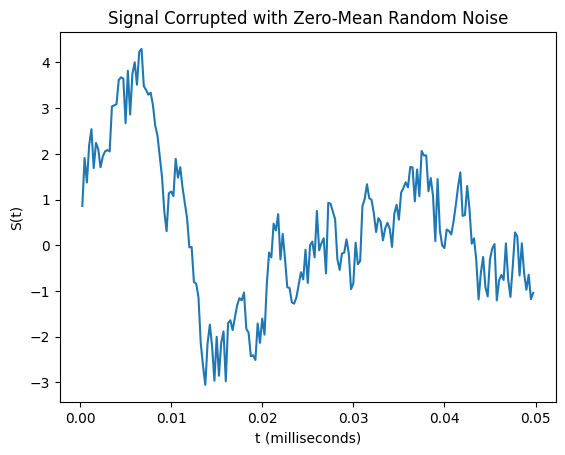

In [1119]:
#Plotting Signal In Time Domain
plt.figure(1)
plt.plot(t[1:200], X[1:200])
plt.title('Signal Corrupted with Zero-Mean Random Noise')
plt.xlabel('t (milliseconds)')
plt.ylabel('S(t)')

In [1120]:
#Computing Fast Fourier Transform (FFT) and Real-Valued Fast Fourier Transform (RFFT) of Noisy Signal X 
Y = rfft(X) 

#Calculating Power Spectrum (PSD)
PSD = np.abs(Y)
freqs = rfftfreq(len(X), 1/Fs)

Text(0, 0.5, '|PSD|')

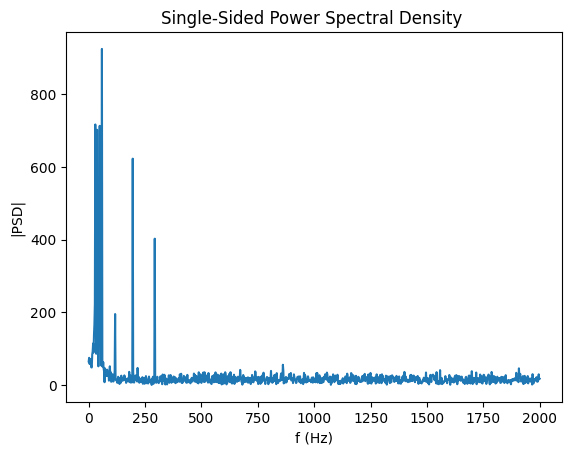

In [1121]:
#Plotting Single-Sided Power Spectral Density
plt.figure()
plt.plot(freqs, PSD)
plt.title('Single-Sided Power Spectral Density ')
plt.xlabel('f (Hz)')
plt.ylabel('|PSD|')

In [1122]:
#Assigning Threshold Value
threshold = 400

In [1123]:
#Finding Freqs With Large PSD
#Taking Out Small Fourier Coeffs In Y
indices = PSD > threshold
Y_zeroed = indices * Y

In [1124]:
#Assigning Filtered FFT (FFILT) Value
#Inverseing FFT For Filtered Time Signal
ffilt = irfft(Y_zeroed)

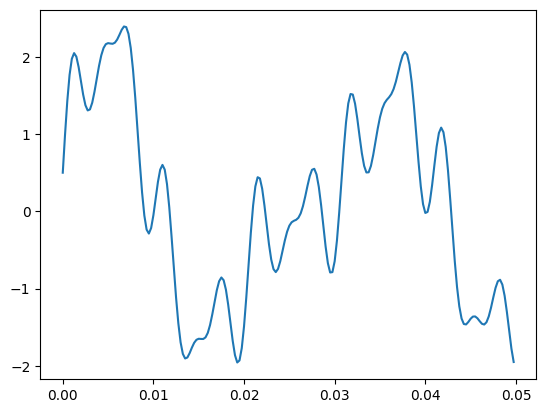

In [1125]:
#Plotting First 200 FFILT Data Points
plt.plot(t[:200], ffilt[:200])
plt.show()

Text(0, 0.5, 'x(t)')

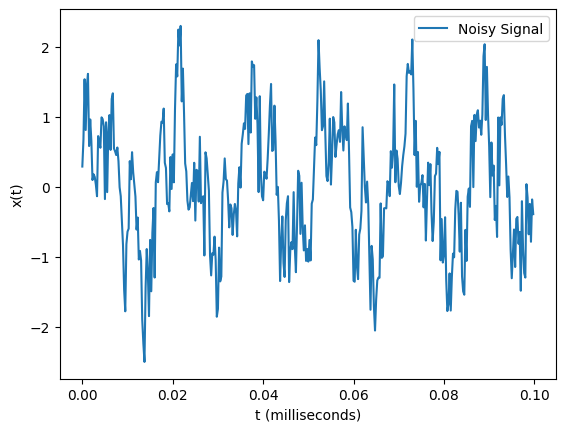

In [1126]:
#Plotting Noisy Signal
plt.plot(t[:400], S_noise[:400], 'tab:blue', label = 'Noisy Signal')
plt.xlabel('t (milliseconds)')
plt.legend(fontsize = 10, loc = 'upper right')
plt.ylabel('x(t)')

In [1127]:
#Defining Size of Average Filter Kernel
kernel_size = 15

In [1128]:
#Creating Average Filter Kernel
average_kernel = np.ones(kernel_size) / 15

In [1129]:
#Convolving Signal with Average Filter Kernel
S_filtered = np.convolve(average_kernel, S_noise, mode = 'same')

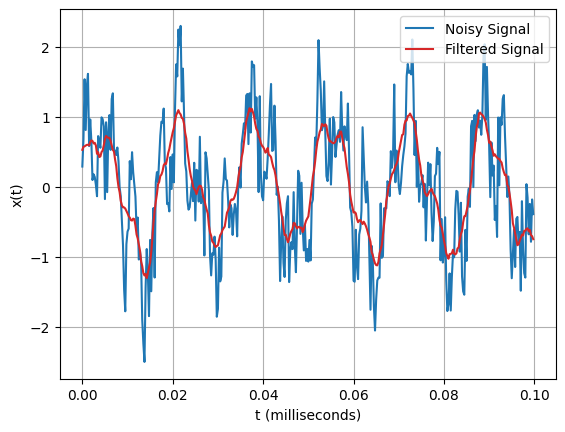

In [1130]:
#Plotting First 400 Points of Noisy and Filtered Signals
plt.plot(t[:400], S_noise[:400], label = 'Noisy Signal')
plt.plot(t[:400], S_filtered[:400], 'tab:red', label = 'Filtered Signal')
plt.xlabel('t (milliseconds)')
plt.legend(fontsize = 10, loc = 'upper right')
plt.ylabel('x(t)')
plt.grid()

In [1131]:
#Defining Parameters of Gaussian Filter
#Standard Deviation (SD) of Gaussian Distribution
sigma = 1.0

#Filter Size
filter_size = 9

In [1132]:
#Creating Array Representing 1D Gaussian Kernel
z = np.linspace(-filter_size // 2, filter_size // 2, filter_size) # uncomment
gaussian_kernel = np.exp(-z ** 2 / (2 * sigma ** 2))
norm_gaussian_kernel = gaussian_kernel / np.sum(gaussian_kernel)  

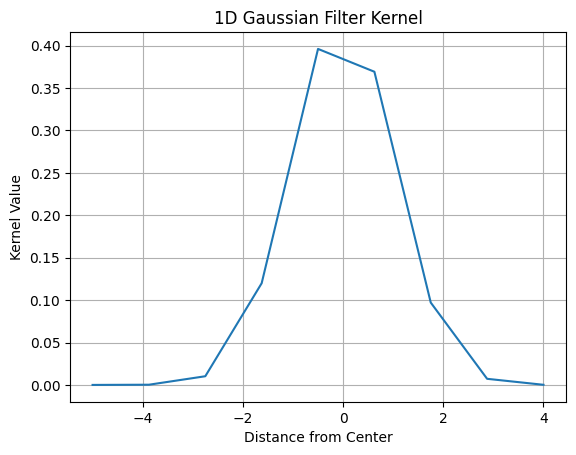

In [1133]:
#Plotting Gaussian Kernel
plt.plot(z, norm_gaussian_kernel)
plt.title('1D Gaussian Filter Kernel')
plt.xlabel('Distance from Center')
plt.ylabel('Kernel Value')
plt.grid(True)
plt.show()

In [1134]:
#Convolving Signal With Average Filter Kernel
S_filtered = np.convolve(norm_gaussian_kernel, S_noise, mode = 'same')

Text(0, 0.5, 'y(t)')

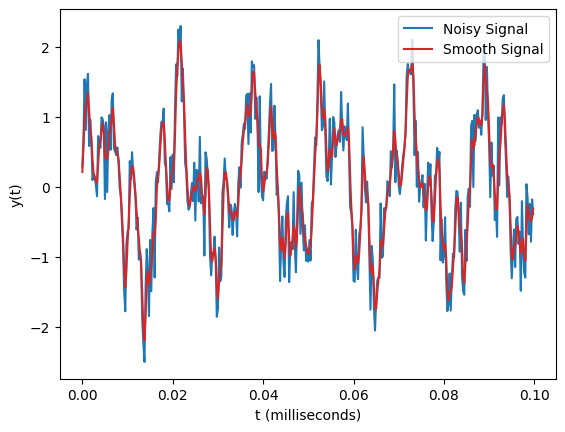

In [1135]:
#Plotting First 400 Points of Noisy and Filtered Signals
plt.plot(t[:400], S_noise[:400], label = 'Noisy Signal')
plt.plot(t[:400], S_filtered[:400], 'tab:red', label = 'Smooth Signal')
plt.xlabel('t (milliseconds)')
plt.legend(fontsize = 10, loc = 'upper right')
plt.ylabel('y(t)')

In [1136]:
a = 0.95
N = 28
n = np.arange(0, N)
lags = np.arange(-(N-1), N)

In [1137]:
#Autocorrelation of Exponential Sequences
s = a ** n
c_auto_corr = np.correlate(s, s, mode = 'full')

In [1138]:
# C Analytically Estimated
nn = np.arange(-(N-1), N, 1/Fs)
c_analytical = (1 - a**(2*(N-np.abs(nn)))) / (1 - a**2) * a**np.abs(nn)

Text(0.5, 0, 'Lag')

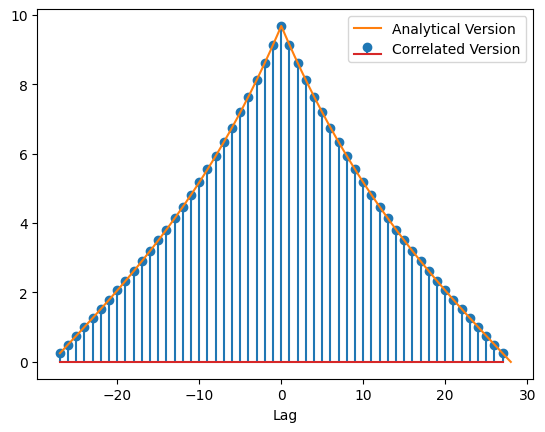

In [1139]:
#Plot Analytical and Correlate Versions
plt.stem(lags, c_auto_corr, label = 'Correlated Version')
plt.plot(nn, c_analytical, 'tab:orange', label = 'Analytical Version')
plt.legend(fontsize = 10, loc = 'upper right')
plt.xlabel('Lag')

In [1140]:
#Change file names to 18, 17, and 34
filename = 'ECGDataset/train/Normal/(30).wav'
fs, x = wavfile.read('ECGDataset/train/Normal/(30).wav')
Dt = 1/fs
T = np.arange(0, 3, Dt)
T = np.linspace(0, len(x) / fs, len(x))

In [1141]:
#Length of Window
M = 128

#Window
g = hann(M, sym = False)

#Overlap of Window
L = 0.75 * M

#Length of FFT
Ndft = 128

In [1142]:
#Using Spectrogram With Explicit Parameters
fx, tx, sx = spectrogram(x, fs = fs, window = g, nperseg = M, noverlap = int(L), nfft = Ndft, scaling = 'spectrum')

In [1143]:
#Using STFT With Explicit Parameters
ft, tt, st = stft(x, fs = fs, window = g, noverlap = int(L), nperseg = M, nfft = Ndft, boundary = None, padded = False, scaling = "spectrum")

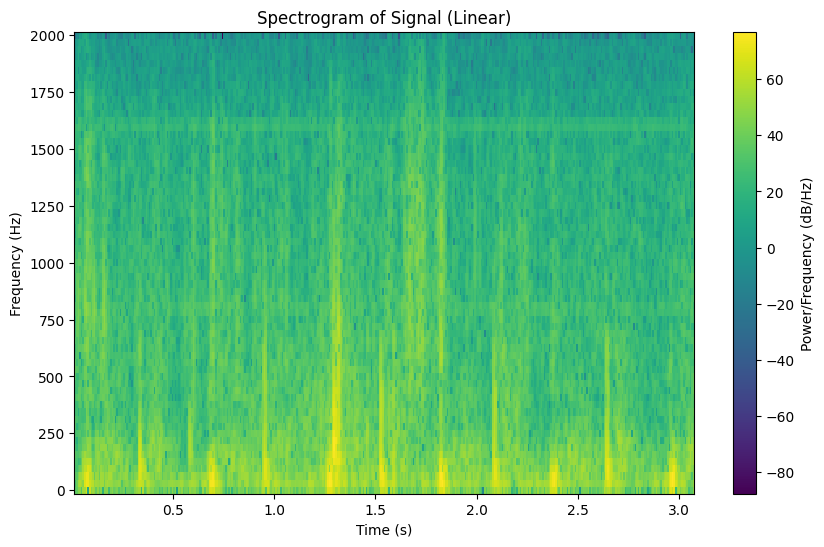

In [1144]:
#Plotting Spectrogram
plt.figure(figsize = (10, 6))
plt.pcolormesh(tx, fx, 10 * np.log10(np.abs(sx)), shading = 'auto')  # Convert to dB
plt.title('Spectrogram of Signal (Linear)')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.colorbar(label = 'Power/Frequency (dB/Hz)')
plt.show()

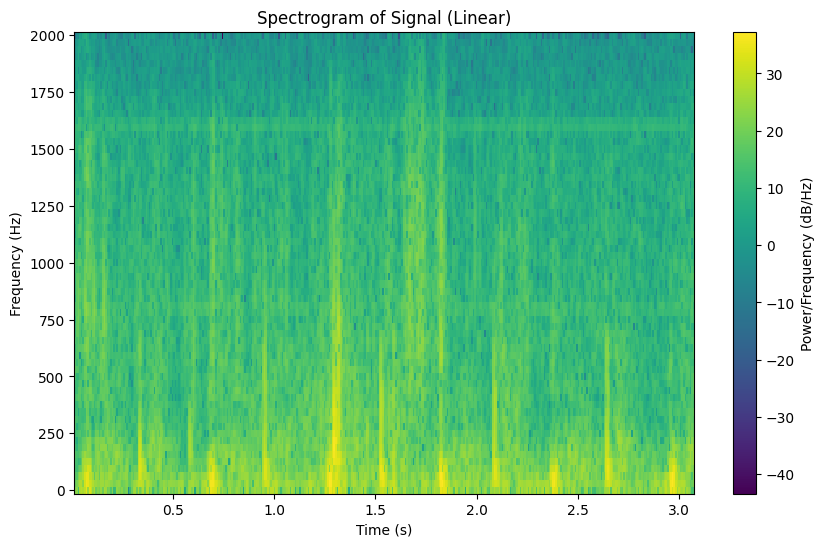

In [1145]:
#Plotting Spectrogram
plt.figure(figsize = (10, 6))
plt.pcolormesh(tt, ft, 10 * np.log10(np.abs(st)), shading = 'auto')  # Convert to dB
plt.title('Spectrogram of Signal (Linear)')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.colorbar(label = 'Power/Frequency (dB/Hz)')
plt.show()

In [1146]:
#Performing Continuous Wavelet Transform (CWT)
wavelet = 'morl'
scales = np.arange(1, 128)
cwt_results, frequencies = pywt.cwt(x, scales, wavelet)

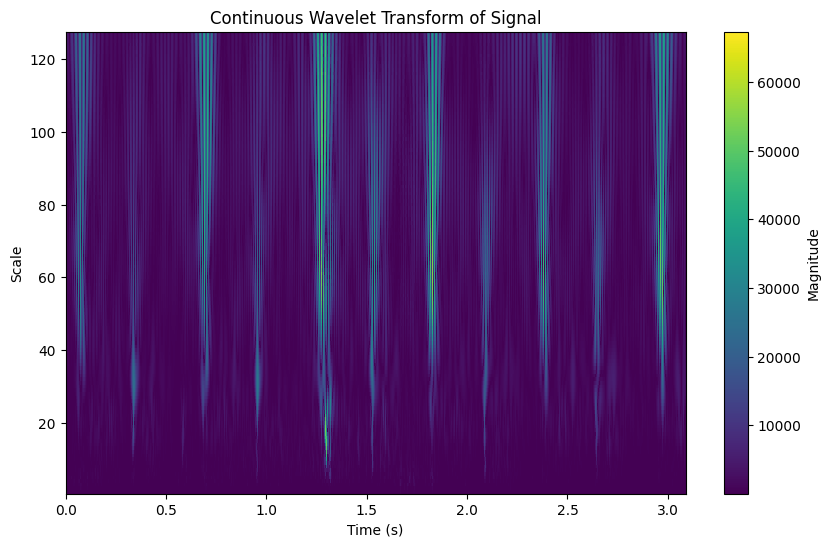

In [1147]:
#Plotting CWT Results
plt.figure(figsize = (10, 6))
plt.pcolormesh(T, scales, np.abs(cwt_results), shading = 'auto')
plt.title('Continuous Wavelet Transform of Signal')
plt.xlabel('Time (s)')
plt.ylabel('Scale')
plt.colorbar(label = 'Magnitude')
plt.show()